In [1]:
library(Seurat)
library(harmony)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)

library(ComplexHeatmap)
library(grid)
library(circlize)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: Rcpp

scatterpie v0.2.6 Learn more at https://yulab-smu.top/



Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


ci

In [2]:
multi_colpalettes<-unique(c(pal_igv("default")(51),pal_npg("nrc")(10),pal_aaas("default")(10),pal_nejm("default")(8),pal_lancet("lanonc")(9),
                      pal_jama("default")(7),pal_jco("default")(10),pal_ucscgb("default")(26),pal_d3("category10")(10),
                      pal_locuszoom("default")(7),
                      pal_uchicago("default")(9),pal_startrek("uniform")(7),
                      pal_tron("legacy")(7),pal_futurama("planetexpress")(12),pal_rickandmorty("schwifty")(12),
                      pal_simpsons("springfield")(16),pal_gsea("default")(12)))
Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')

In [3]:
readRDS_downsample <- function(path,size=40000){
    obj <- readRDS(path)
    obj@reductions$pca@assay.used <- 'RNA'
    obj <- obj[,sample(ncol(obj), size)]
    gc()
    return(obj)
}

In [4]:
obj_marm <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Marmoset_combined_OG.rds')
obj_mous <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Mouse_combined_OG.rds')
obj_bird <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Bird_combined_OG.rds')
obj_turt <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Turtle_combined_OG.rds')
obj_axol <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Axolotl_combined_OG.rds')
obj_lung <- readRDS_downsample('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/LungFish_combined_OG.rds')

In [5]:
obj_marm$batch <- 'marm_batch1'
obj_mous$batch <- paste0('mous_',obj_mous$batchId)
obj_turt$batch <- paste0('turt_',obj_turt$batch)
obj_bird$batch <- paste0('bird_',obj_bird$sampleName)
obj_axol$batch <- paste0('axol_',obj_axol$regions)
obj_lung$batch <- paste0('lung_batch',c('brain_1'='1','brain_2'='1','brain_3'='2','brain_4'='2','brain_5'='3','brain_6'='3')[obj_lung$orig.ident])

In [7]:
obj_marm$annotation <- obj_marm$Subclass
obj_mous$annotation <- obj_mous$Cell_group
obj_turt$annotation <- obj_turt$cell.type
obj_bird$annotation <- obj_bird$cell.type
obj_axol$annotation <- obj_axol$subclasses
obj_lung$annotation <- obj_lung$subtype

obj_marm@meta.data$Class <- c('EX'='EX','IN'='IN','NonNeu'='NN')[obj_marm$Class]
obj_mous@meta.data$Class <- c('Astrocytes'='NN','Telencephalon excitatory neurons'='EX','Endothelial cells'='NN','Oligodendrocytes'='NN',
                    'Vascular and leptomeningeal cells'='NN','Telencephalon inhibitory neurons'='IN','Microglia'='NN',
                    'Oligodendrocyte precursor cells'='NN','Di- and mesencephalon neurons'='EX','Cholinergic, monoaminergic, peptidergic neurons'='IN',
                    'Ependymal cells'='NN','Olfactory bulb inhibitory neurons'='IN','Dentate gyrus granule neurons'='EX','Olfactory bulb excitatory neurons'='EX')[obj_mous$Cell_subclass]
obj_turt@meta.data$Class <- c('OPC'='NN','ASTOR'='NN','Oligo'='NN','MIC'='NN','EX'='EX',
                    'LGE_striatum'='IN','LGE_amygdala'='IN','MGE_PV'='IN','MGE_SST'='IN','SNCG'='IN','CGE_VIP'='IN')[obj_turt$cell.type]
obj_bird@meta.data$Class <- c('EX'='EX','MGE_PVALB'='IN','Astro'='NN','CGE_VIP_like'='IN','LGE'='IN',
                    'Neuroblast'='EX','Oligo'='NN','MGE_SST'='IN','Microgila'='NN','VLMC'='NN',
                    'SNCG'='IN','Endo'='NN','OPC'='NN','CGE_Lamp5'='IN','Blood'='NN')[obj_bird$cell.type]
obj_axol@meta.data$Class <- c('Glutamatergic'='EX','GABAergic'='IN','Ependymal'='NN','NPC'='EX','endothelial'='NN','oligodendrocyte'='NN','microglia'='NN')[obj_axol$subclasses]
obj_lung@meta.data$Class <- c('Glu'='EX','GABA.1'='IN','GABA.2'='IN','GABA.3'='IN','Oligo'='NN','MG'='NN','EG.1'='NN','Endo.1'='NN','EG.2'='NN','Endo.2'='NN')[obj_lung$subtype]

obj_marm@meta.data <- obj_marm@meta.data[,c('batch','Class','annotation')]
obj_mous@meta.data <- obj_mous@meta.data[,c('batch','Class','annotation')]
obj_turt@meta.data <- obj_turt@meta.data[,c('batch','Class','annotation')]
obj_bird@meta.data <- obj_bird@meta.data[,c('batch','Class','annotation')]
obj_axol@meta.data <- obj_axol@meta.data[,c('batch','Class','annotation')]
obj_lung@meta.data <- obj_lung@meta.data[,c('batch','Class','annotation')]

In [8]:
obj.list <- c(
    lapply(unique(obj_marm$batch),function(x){return(obj_marm[,obj_marm$batch==x])}),
    lapply(unique(obj_mous$batch),function(x){return(obj_mous[,obj_mous$batch==x])}),
    lapply(unique(obj_turt$batch),function(x){return(obj_turt[,obj_turt$batch==x])}),
    lapply(unique(obj_bird$batch),function(x){return(obj_bird[,obj_bird$batch==x])}),
    lapply(unique(obj_axol$batch),function(x){return(obj_axol[,obj_axol$batch==x])}),
    lapply(unique(obj_lung$batch),function(x){return(obj_lung[,obj_lung$batch==x])}))

In [10]:
for (i in 1:length(obj.list)) {
    obj.list[[i]] <- NormalizeData(obj.list[[i]], verbose = FALSE)
    obj.list[[i]] <- FindVariableFeatures(object = obj.list[[i]],nfeatures = 5000)
    obj.list[[i]] <- ScaleData(object = obj.list[[i]],verbose = F)
    obj.list[[i]] <- RunPCA(object = obj.list[[i]],verbose = F)
}

In [ ]:
#reference.seq = seq(from=1,by=2,length=11)
features <- SelectIntegrationFeatures(object.list = obj.list,nfeatures = 5000)
obj.anchors <- FindIntegrationAnchors(object.list = obj.list, anchor.features = features, reduction = "rpca")
obj_merge <- IntegrateData(anchorset = obj.anchors,k.weight = min(table(paste0(obj.anchors@anchors$dataset1,'_',obj.anchors@anchors$dataset2)))-1)

DefaultAssay(obj_merge) <- "integrated"
obj_merge <- ScaleData(obj_merge, verbose = FALSE)
obj_merge <- RunPCA(obj_merge,verbose = F,npcs=30)
obj_merge$species <- gsub('_.*','',obj_merge$batch)
obj_merge <- RunHarmony(obj_merge,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj_merge <- RunUMAP(obj_merge,reduction = 'harmony',dims=1:30,verbose = F)
obj_merge <- RunUMAP(obj_merge,reduction = 'pca',dims=1:30,reduction.name = 'umap_pca',verbose = F)

obj_merge <- FindNeighbors(obj_merge,reduction = 'umap',dims=1:2,verbose = F)
obj_merge <- FindClusters(obj_merge,verbose = F,resolution=0.05)

In [34]:
obj_merge <- obj_merge[,obj_merge$annotation!='EG.2']
obj_merge <- obj_merge[,obj_merge$integrated_snn_res.0.05!=19]
obj_merge <- ScaleData(obj_merge, verbose = FALSE)
obj_merge <- RunPCA(obj_merge,verbose = F,npcs=30)
obj_merge <- RunHarmony(obj_merge,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')

obj_merge <- RunUMAP(obj_merge,reduction = 'harmony',dims=1:30,verbose = F)
obj_merge <- RunUMAP(obj_merge,reduction = 'pca',dims=1:30,reduction.name = 'umap_pca',verbose = F)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 11796200)”
Warning message:
“Key ‘UMAP_’ taken, using ‘umappca_’ instead”


In [4]:
obj <- readRDS(paste0('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/Marmoset_combined_OG.rds'))

In [23]:
#add unassign orthgroup
#obj_merge <- readRDS('obj_merge.rds')
#obj.list <- lapply(c('Marmoset','Mouse','Bird','Turtle','Axolotl','LungFish'),function(x){
#    obj <- readRDS(paste0('/mnt/gandan/huangzhi/brain/01.Raw_file/Multi_species/01.RNA/',x,'_combined_OG.rds'))
#    obj <- obj[,colnames(obj)%in%colnames(obj_merge)]
#    return(obj)
#})
#obj_merge_assays <- merge(obj.list[[1]],obj.list[-1])
#
#new_assyas <- CreateAssayObject(obj_merge_assays[['RNA']]@counts[,colnames(obj_merge[['RNA']])])
#obj_merge[['RNA']] <- new_assyas

In [31]:
obj_merge <- readRDS('obj_merge_final_20251112.rds')

pdf 
  2

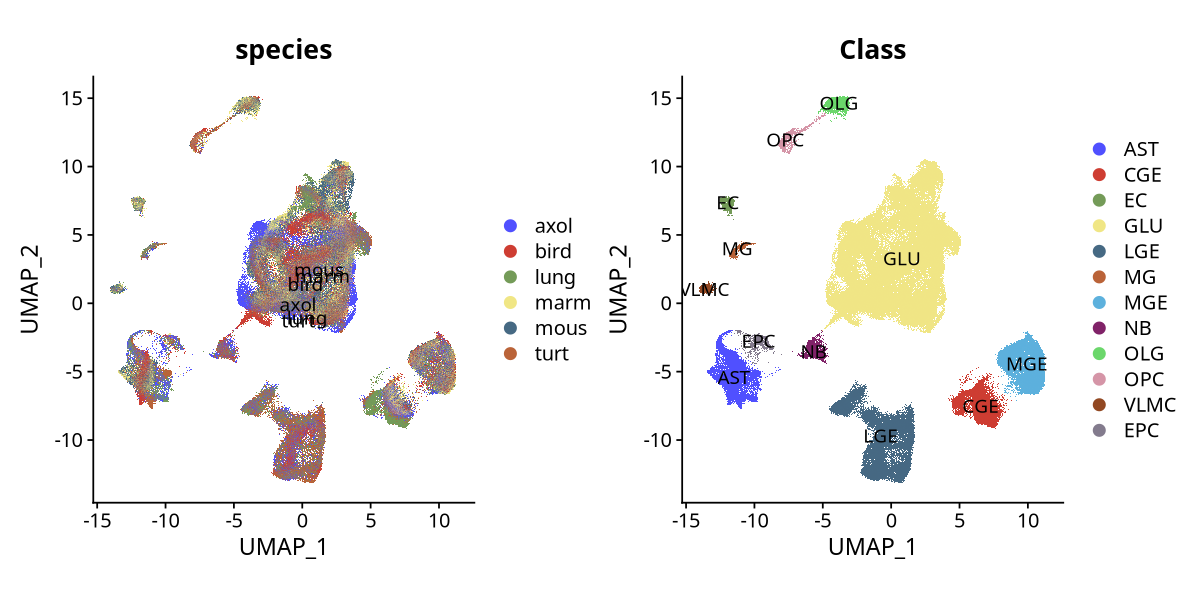

In [39]:
options(repr.plot.height=5,repr.plot.width=10)
p1 <- DimPlot(obj_merge,reduction = 'umap',group.by='species',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()+
ggtitle('species')
p2 <- DimPlot(obj_merge,reduction = 'umap',group.by='Class',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC','EPC'))+
coord_fixed()+
ggtitle('Class')
p1|p2
pdf('Plot/All_UMAP_Class.pdf',width=10,height=5)
p1|p2
dev.off()

pdf 
  2

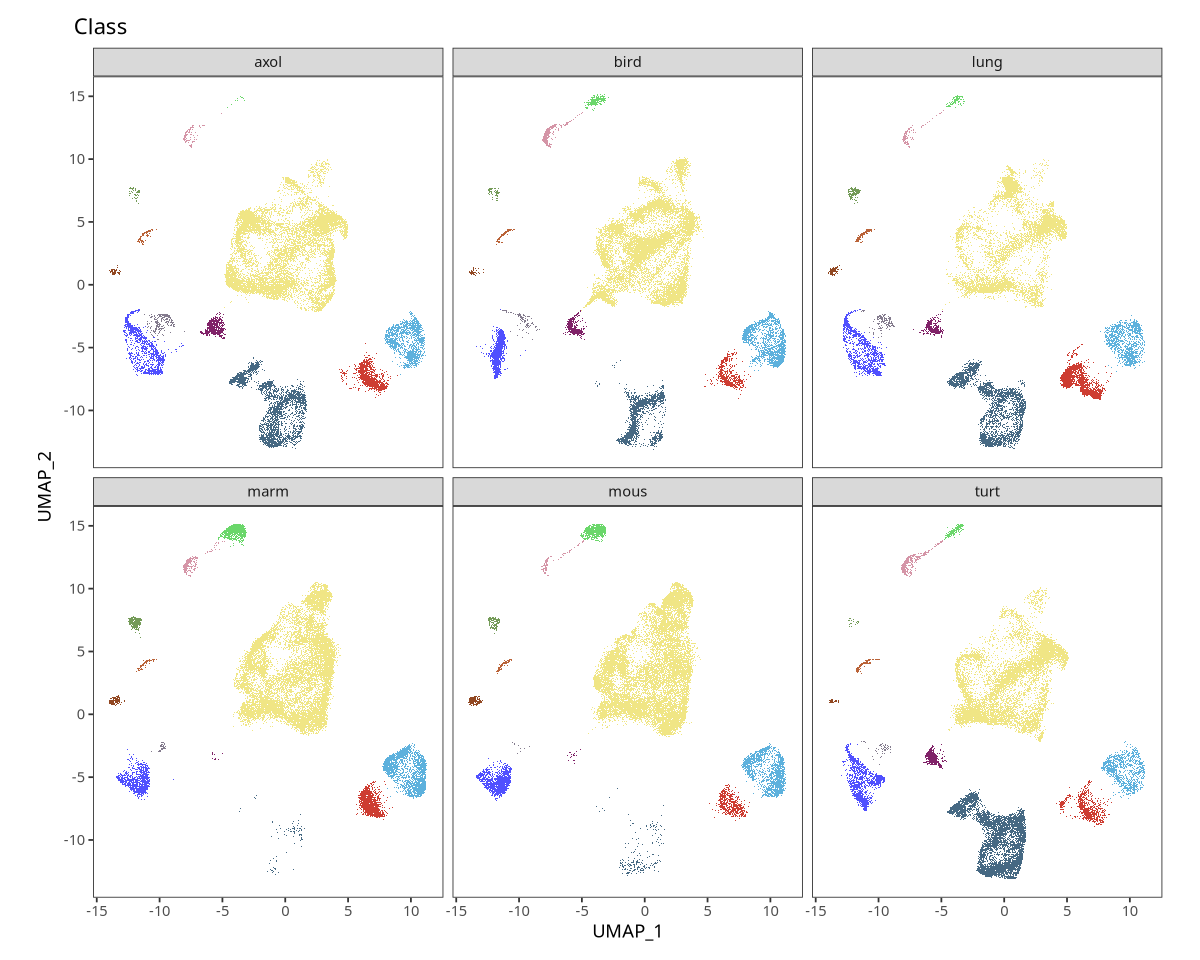

In [40]:
options(repr.plot.height=8,repr.plot.width=10)
p <- DimPlot(obj_merge,reduction = 'umap',group.by='Class',split.by = 'species',raster = T,label=F,ncol=3)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC','EPC'))+
coord_fixed()+
theme_test()+
NoLegend()
p
pdf('Plot/All_UMAP_Class_species.pdf',width=20,height=5)
p
dev.off()

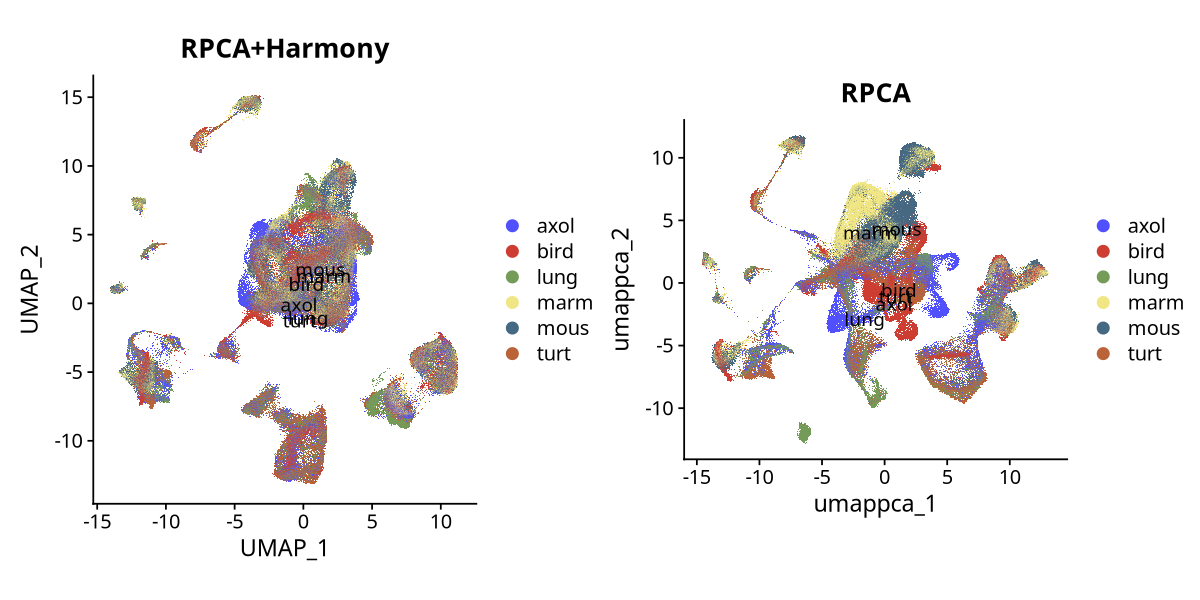

In [35]:
options(repr.plot.height=5,repr.plot.width=10)
p1 <- DimPlot(obj_merge,reduction = 'umap',group.by='species',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()+
ggtitle('RPCA+Harmony')
p2 <- DimPlot(obj_merge,reduction = 'umap_pca',group.by='species',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()+
ggtitle('RPCA')
p1|p2

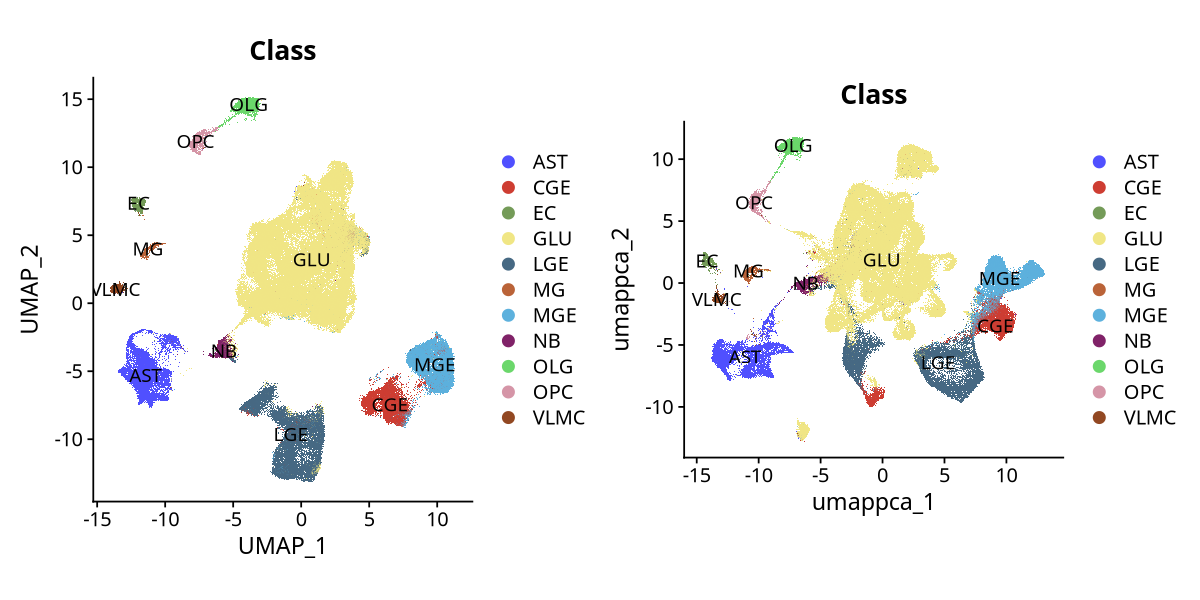

In [36]:
options(repr.plot.height=5,repr.plot.width=10)
p1 <- DimPlot(obj_merge,reduction = 'umap',group.by='Class',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC'))+
coord_fixed()
p2 <- DimPlot(obj_merge,reduction = 'umap_pca',group.by='Class',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC'))+
coord_fixed()
p1|p2

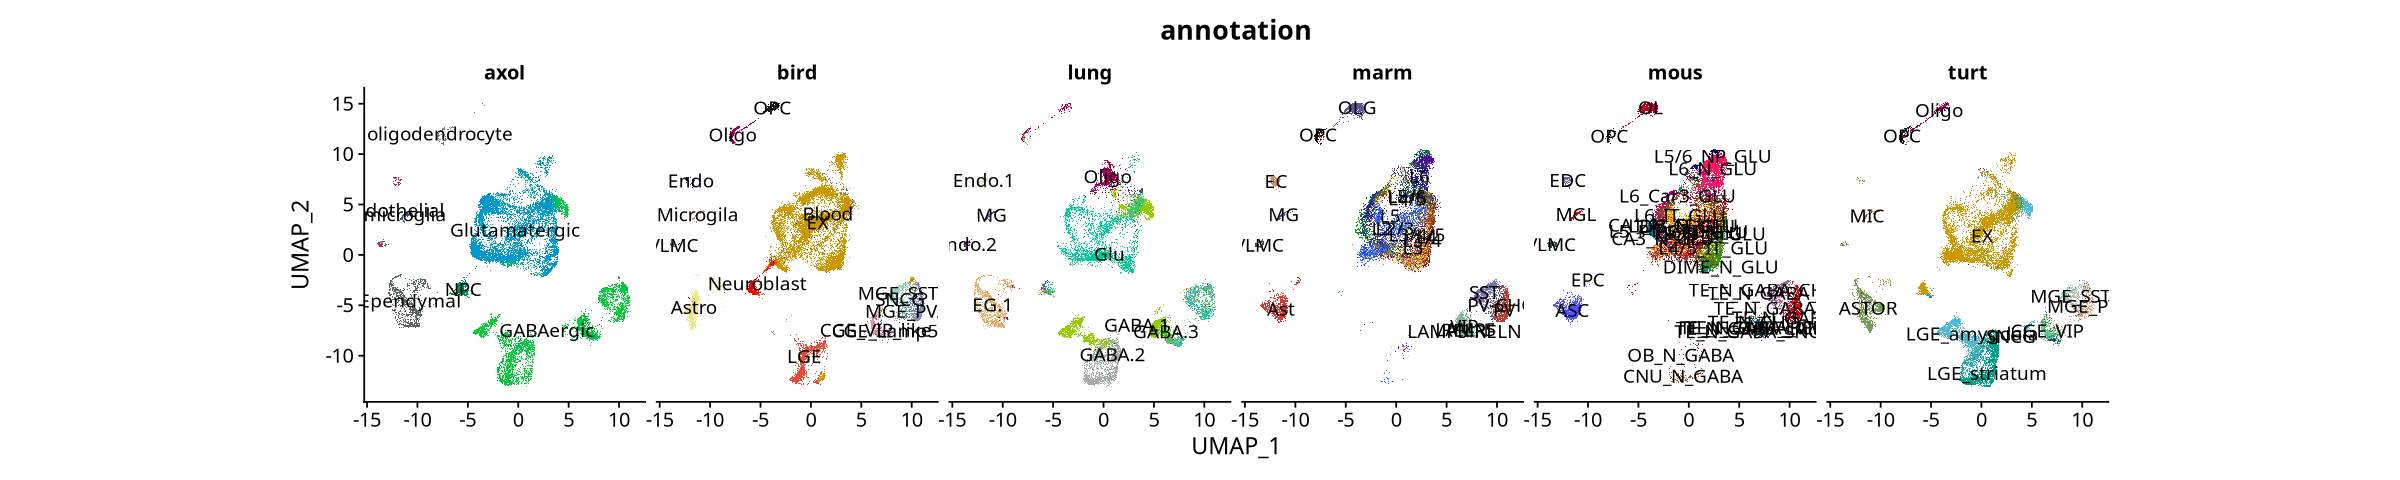

In [37]:
options(repr.plot.height=4,repr.plot.width=20)
DimPlot(obj_merge,reduction = 'umap',group.by='annotation',split.by = 'species',raster = T,label=T,ncol=6)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed()+
NoLegend()

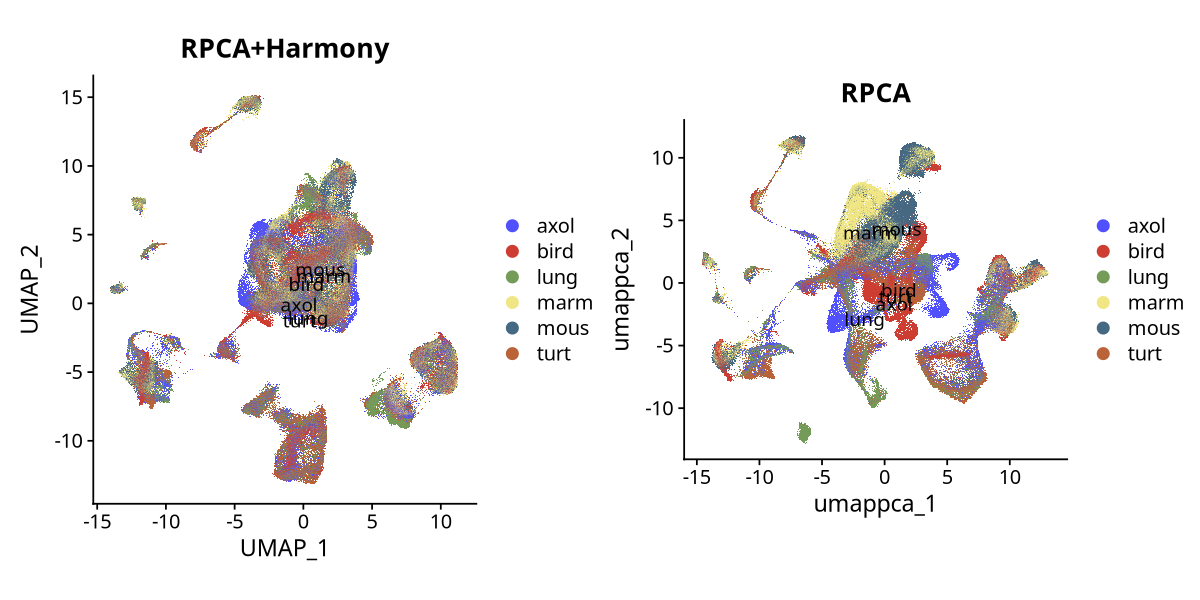

In [38]:
options(repr.plot.height=5,repr.plot.width=10)
p1 <- DimPlot(obj_merge,reduction = 'umap',group.by='species',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()+
ggtitle('RPCA+Harmony')
p2 <- DimPlot(obj_merge,reduction = 'umap_pca',group.by='species',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()+
ggtitle('RPCA')
p1|p2

In [40]:
obj_merge <- FindNeighbors(obj_merge,reduction = 'umap',dims=1:2,verbose = F)
obj_merge <- FindClusters(obj_merge,verbose = F,resolution=0.1)

In [42]:
obj_merge <- FindClusters(obj_merge,verbose = F,resolution=0.2)

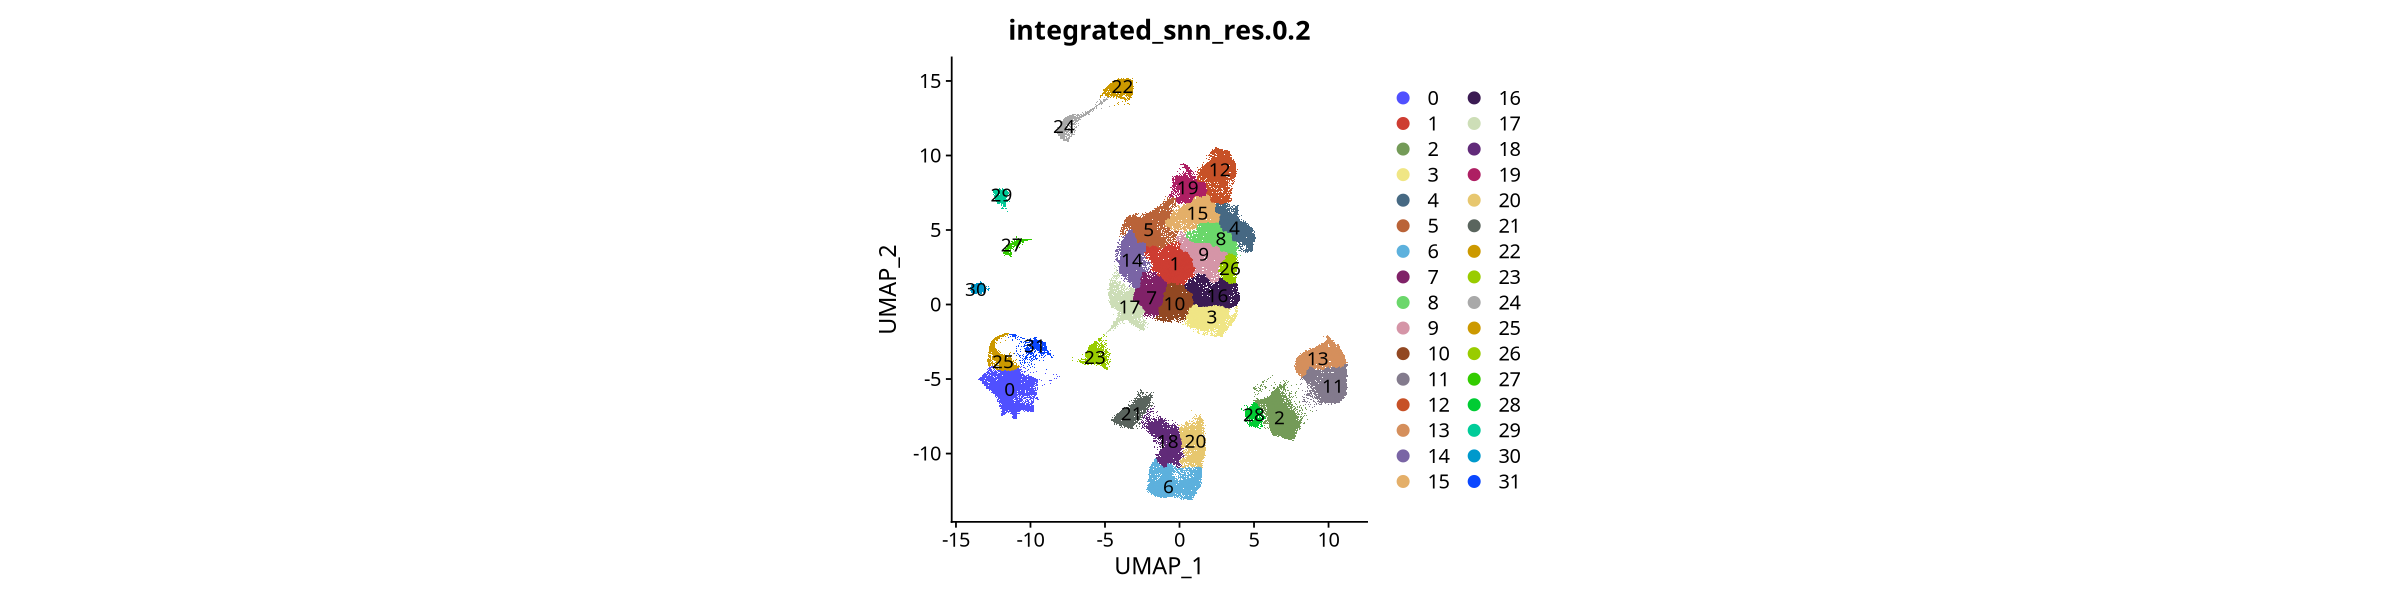

In [43]:
options(repr.plot.height=5,repr.plot.width=20)
DimPlot(obj_merge,reduction = 'umap',group.by='integrated_snn_res.0.2',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()

In [45]:
obj_merge@meta.data$raw_Class <- obj_merge@meta.data$Class
obj_merge@meta.data$Class <- 'GLU'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(11,13),]$Class <- 'MGE'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(28,2),]$Class <- 'CGE'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(21,18,20,6),]$Class <- 'LGE'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(22),]$Class <- 'OLG'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(24),]$Class <- 'OPC'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(30),]$Class <- 'VLMC'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(27),]$Class <- 'MG'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(29),]$Class <- 'EC'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(0,25),]$Class <- 'AST'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(31),]$Class <- 'EPC'
obj_merge@meta.data[obj_merge$integrated_snn_res.0.2%in%c(23),]$Class <- 'NB'

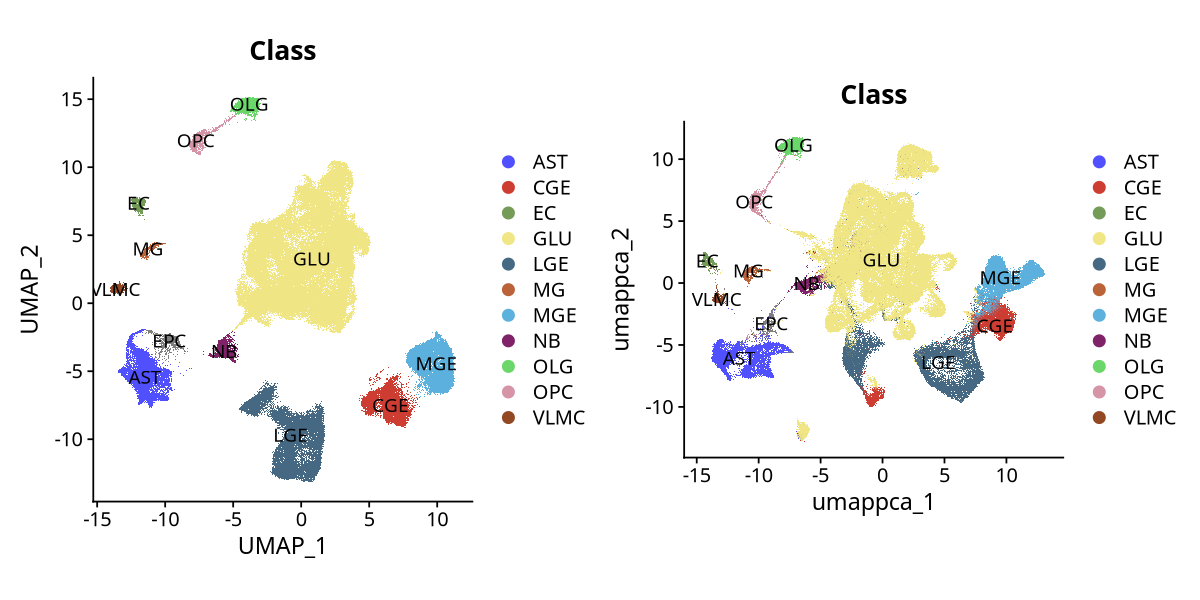

In [46]:
options(repr.plot.height=5,repr.plot.width=10)
p1 <- DimPlot(obj_merge,reduction = 'umap',group.by='Class',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC','EPC'))+
coord_fixed()
p2 <- DimPlot(obj_merge,reduction = 'umap_pca',group.by='Class',raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)),breaks = c('AST','CGE','EC','GLU','LGE','MG','MGE','NB','OLG','OPC','VLMC','EPC'))+
coord_fixed()
p1|p2

In [47]:
saveRDS(obj_merge,'Analysis/obj_merge_final_20251112.rds')
source('../R_function/Seurat_function.R')
save_seurat_key(obj_merge,'Analysis/','obj_merge_final_20251112')

In [48]:
saveRDS(obj_merge[,obj_merge$Class=='GLU'],'obj_GLU.rds')
saveRDS(obj_merge[,obj_merge$Class%in%c('MGE','CGE','LGE')],'obj_GABA.rds')
saveRDS(obj_merge[,obj_merge$Class%in%c('OLG','OPC','EC','MG','VLMC','AST','EPC')],'obj_NN.rds')

In [2]:
obj_merge_key <- readRDS('Analysis/obj_merge_final_20251112_keys.rds')

In [3]:
table(obj_merge_key$meta.data$species)


 axol  bird  lung  marm  mous  turt 
39947 39967 36035 39997 39986 39992 

In [334]:
obj_merge <- readRDS('Analysis/obj_merge.rds')
obj_merge <- read_seurat_key(obj_merge,'Analysis/obj_merge_final_20251112_keys.rds')

In [17]:
source('../R_function/Seurat_function.R')
save_seurat_key(obj_merge,'/mnt/gandan/huangzhi/jupyter/Multispecies/','obj_merge')

In [2]:
library(ggplot2)

In [11]:
obj_merge_keys <- readRDS('obj_merge_final_20251112_keys.rds')
tmp_df <- obj_merge_keys$meta.data
tmp_df[tmp_df$species=='bird'&tmp_df$annotation%in%c('Oligo','OPC'),'annotation'] <- c('Oligo'='OPC','OPC'='Oligo')[tmp_df[tmp_df$species=='bird'&tmp_df$annotation%in%c('Oligo','OPC'),'annotation']]
intersection_matrix <- table(paste0(tmp_df$species,'_',tmp_df$annotation),tmp_df$Class)
intersection_norm <- intersection_matrix/rowSums(intersection_matrix)
intersection_df <- as.data.frame(intersection_norm)


intersection_df$species <- gsub('_.*','',as.character(intersection_df$Var1))
intersection_df$Var1 <- gsub('axol_|bird_|lung_|marm_|mous_|turt_','',as.character(intersection_df$Var1))
#intersection_df$Var1 <- as.character(intersection_df$Var1)

In [29]:
intersection_df$Var2 <- factor(intersection_df$Var2,levels = rev(c('GLU','MGE','CGE','LGE','NB','AST','OLG','OPC','MG','EC','VLMC','EPC')))
X_order <- c('Glutamatergic','EX','CA1_N_GLU','CA3_N_GLU','DG_N_GLU','DIME_N_GLU',
             'Glu','L2','L2/3','L2/3_IT_GLU','L3','L3/4','L3/4/5','L4','L4/5','L4/5_IT_GLU','L5','L5_IT_GLU','L5_PT_GLU',
             'L5/6','L5/6_NP_GLU','L6','L6_Car3_GLU','L6_IT_GLU','L6_N_GLU','OB_N_GLU','TE_N_GLU','Blood',
             #MGE
             'MGE_PVALB','MGE_PV','MGE_SST','SNCG','PV','PV-CHC','SST','TE_N_GABA_CHODL','TE_N_GABA_PVALB','TE_N_GABA_SST','TE_N_GABA',
             #CGE
             'CGE_Lamp5','CGE_VIP','CGE_VIP_like','GABA.3','LAMP5','LAMP5-RELN','RELN','VIP','TE_N_CHO','TE_N_GABA_LAMP5','TE_N_GABA_RELN','TE_N_GABA_SNCG','TE_N_GABA_VIP',
             #LGE
             'GABAergic','GABA.2','GABA.1','CNU_N_GABA','OB_N_GABA','LGE','LGE_amygdala','LGE_striatum',
             #NB
             'NPC','Neuroblast',
             #AST
             'Ependymal','Astro','ASTOR','Ast','ASC','EG.1',
             #OLG
             'OL','OLG','Oligo','oligodendrocyte',
             #OPC
             'OPC',
             #MG
             'MGL','MIC','Microgila','microglia','MG',
             #EC
             'endothelial','Endo','Endo.1','EC','EDC',
             #VLMC
             'VLMC','Endo.2',
             #EPC
             'EPC'
             )
intersection_df$Var1 <- factor(intersection_df$Var1,levels = X_order)
intersection_df$species <- factor(intersection_df$species,levels = c('marm','mous','bird','turt','axol','lung'))

pdf 
  2

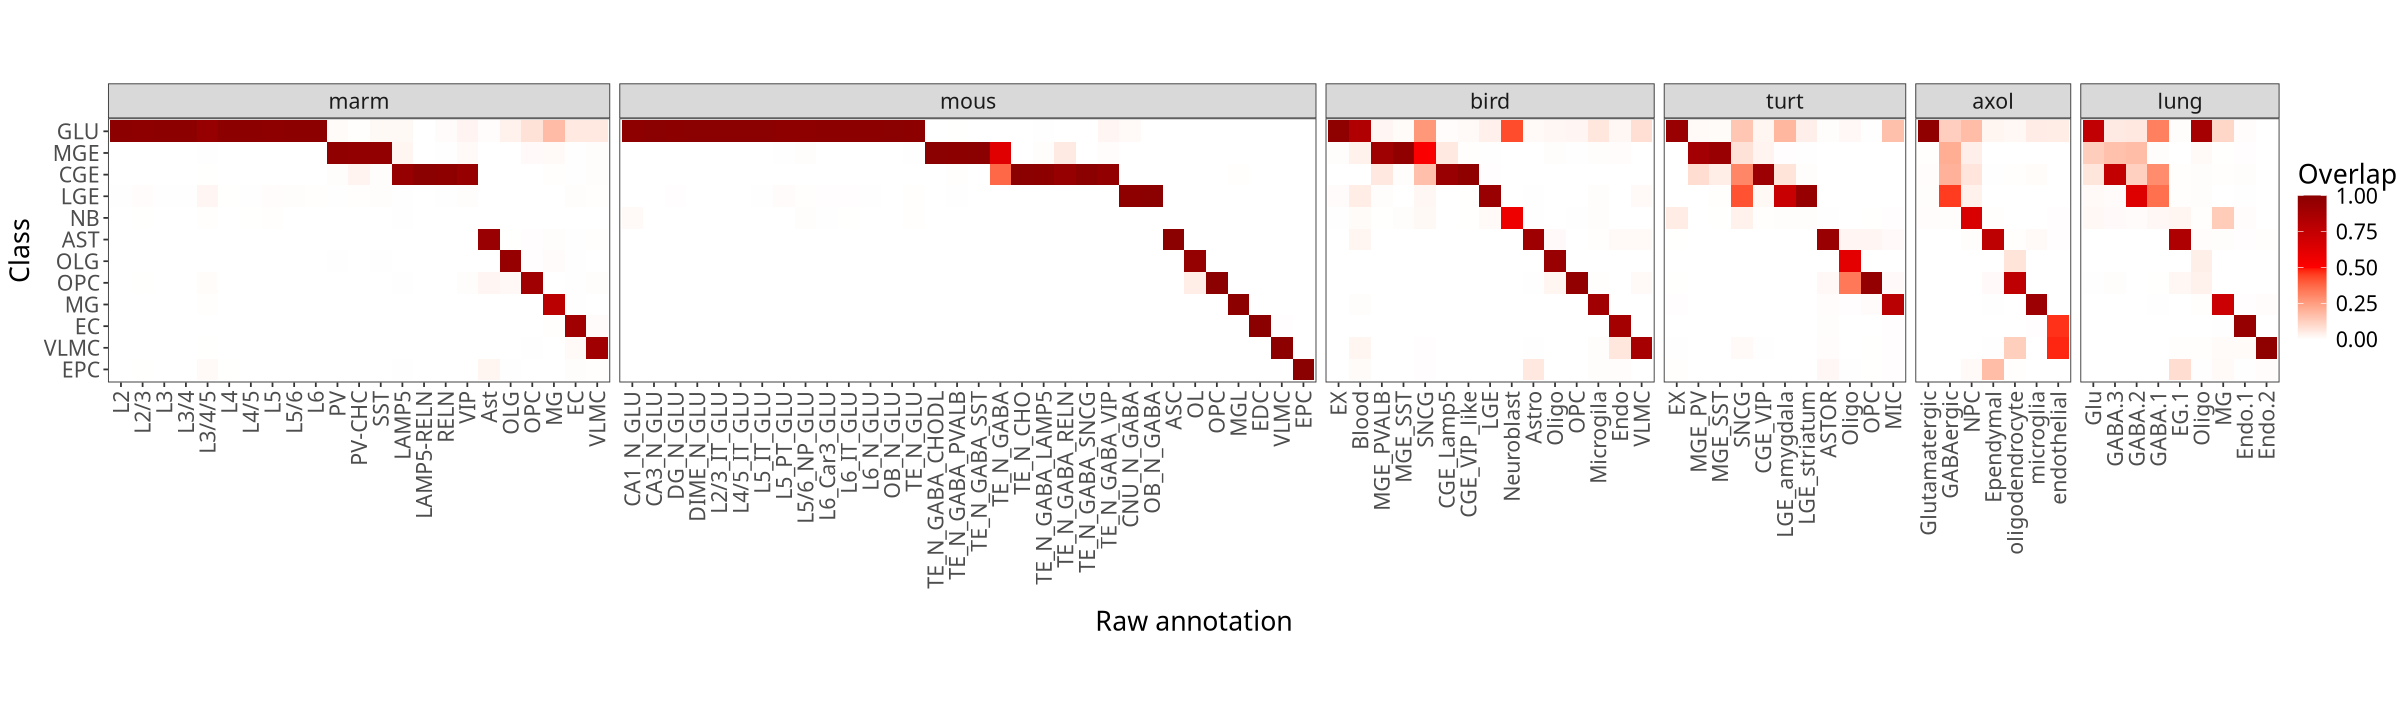

In [41]:
options(repr.plot.height=6,repr.plot.width=20)
p <- ggplot()+
geom_tile(data=intersection_df,aes(x=Var1,y=Var2,fill=Freq),width=1, height=1)+
ggh4x::facet_grid2(~species, scales = "free", space ="free")+
scale_fill_gradientn(colours = c('white','red','darkred'),name='Overlap')+
theme_test()+
theme(aspect.ratio=1,text=element_text(size=16),axis.text.x = element_text(angle=90,hjust=1,vjust=0.5))+
xlab('Raw annotation')+
ylab('Class')
p
pdf('Plot/All_heatmap_overlap_with_Raw_annotation.pdf',width=20,height=6)
p
dev.off()

In [8]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- Archr_col[1:17]
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','bird','turt','axol','lung','lamp')

In [4]:
obj_merge <- readRDS('obj_merge_final_20251112.rds')

In [28]:
obj_merge@active.assay <- 'RNA'
obj_merge <- NormalizeData(obj_merge)

In [2]:
OG_gene <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups.tsv',sep='\t',row.names = 1)
OG_gene2 <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups_UnassignedGenes.tsv',sep='\t',row.names = 1)
OG_gene <- rbind(OG_gene,OG_gene2)
obj_merge@assays$RNA@meta.features <- OG_gene[rownames(obj_merge),]

In [3]:
OG_gene[grep('SEMA7A',OG_gene$Marmoset.pep),]

,Axolotl.pep,Bird.pep,Fish.pep,Lamprey.pep,Lungfish.pep,Marmoset.pep,Mouse.pep,Turtle.pep
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
OG0009579,AMEX60DD003916,SEMA7A,sema7a,,SEMA7A,SEMA7A,Sema7a,SEMA7A


In [ ]:
marker_list <- list(
'Neuron'=c('OG0003094'='SNAP25'),
'IN'=c('OG0009142'='GAD1','OG0010353'='GAD2','OG0003332'='SLC6A1'),
'EX'=c('OG0000947'='SLC17A6/7/8'),
'CGE'=c('OG0010349'='ADARB2'),
'MGE'=c('OG0001689'='LHX6'),
'LGE'=c('OG0001296'='MEIS2'),
'Ast'=c('OG0004414'='AQP4','OG0000526'='FGFR1/2/3/4','OG0002798'='SLC14A1','OG0001962'='SLC1A3/6'),
'OPC'=c('OG0008530'='PDGFRA','OG0011351'='OLIG2'),
'OLG'=c('OG0011024'='MBP','OG0008124'='PLP1','OG0010121'='MAG'),
'EC'=c('OG0000528'='EBF1/2/3/4','OG0006712'='ITIH5','OG0002707'='BGN','OG0000507'='KDR/FLT1/4'),
'MG'=c('OG0012013'='TYROBP','OG0000429'='C3','OG0014439'='CX3CR1')
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


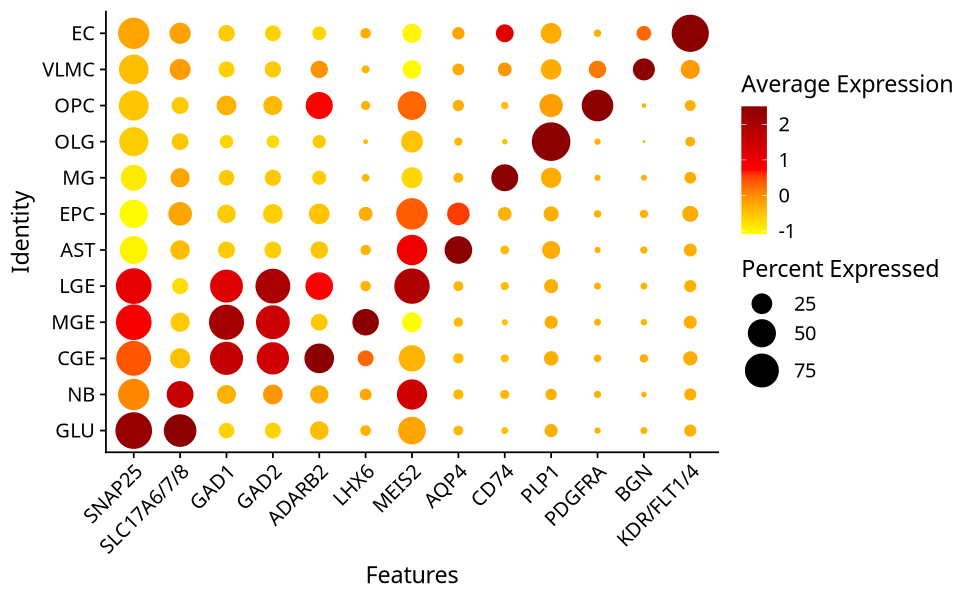

In [47]:
x_labels <- c('SNAP25',
              'SLC17A6/7/8',
              'GAD1','GAD2',
              'ADARB2','LHX6','MEIS2',
              'AQP4',
              'CD74',
              'PLP1',
              'PDGFRA',
              'BGN',
              'KDR/FLT1/4'
              )
obj_merge$Class <- factor(obj_merge$Class, levels = c('GLU','NB','CGE','MGE','LGE','AST','EPC','MG','OLG','OPC','VLMC','EC'))
p <- DotPlot(obj_merge,group.by = 'Class',features = c('OG0003094',
                                                       'OG0000947',
                                                       'OG0009142','OG0010353',
                                                       'OG0010349','OG0001689','OG0001296',
                                                       'OG0004414',
                                                       'OG0007762',
                                                       'OG0008124',
                                                       'OG0008530',
                                                       'OG0002707',
                                                       'OG0000507'),assay = 'RNA')+
scale_x_discrete(labels= x_labels)+
scale_color_gradientn(colours = c('yellow','red','darkred'))+
scale_size(range = c(0,10))+
theme(axis.text.x = element_text(angle=45,hjust=1,vjust=1))
options(repr.plot.height=5,repr.plot.width=8)
p

In [48]:
pdf('Plot/All_Dotplot_marker.pdf',height=5,width=8)
p
dev.off()

pdf 
  2

In [25]:
source('../R_function/calculate_function.R')
Ave_inter <- as.data.frame(t(matrix_groupby(matrix_input = obj_merge@reductions$harmony@cell.embeddings, group.by = paste0(obj_merge$Class,'_',obj_merge$species),cal = 'mean', type='row')))

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



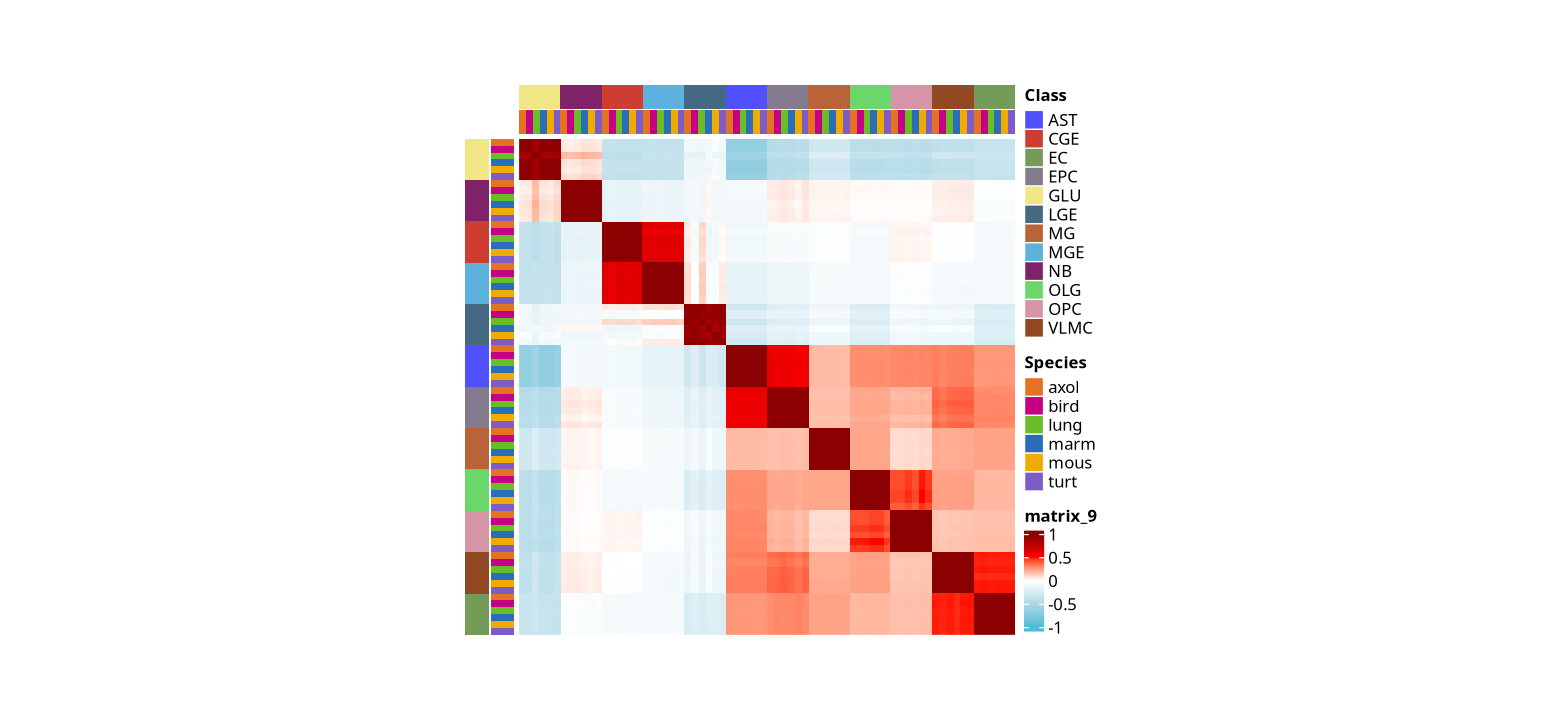

In [26]:
Ave_inter <- dplyr::bind_cols(lapply(c('GLU','NB','CGE','MGE','LGE','AST','EPC','MG','OLG','OPC','VLMC','EC'),function(x){
return(Ave_inter[,gsub('_.*','',colnames(Ave_inter))==x])}))

row_annotation <- rowAnnotation(Class = gsub('_.*','',colnames(Ave_inter)),show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter)),
                                   col=list(
                                   Class=Class_color,
                                   Species=Species_color))
col_annotation <- columnAnnotation(Class = gsub('_.*','',colnames(Ave_inter)),show_legend = FALSE,show_annotation_name = FALSE,
                                   Species = gsub('.*_','',colnames(Ave_inter)),
                                   col=list(
                                   Class=Class_color,
                                   Species=Species_color))

p1 <- as.ggplot(ComplexHeatmap::Heatmap(cor(Ave_inter),cluster_rows = F,cluster_columns = F,show_column_names = F,show_row_names = F,
                                        left_annotation = row_annotation,top_annotation = col_annotation,
                                        col = colorRamp2(c(-1,-0.5,0, 0.5, 1), c('#4DBBD5','lightblue','white','red','darkred')),
                                        width =ncol(Ave_inter)*unit(1.45833, "mm"),height=ncol(Ave_inter)*unit(1.45833, "mm"),use_raster = TRUE
                                       ))
options(repr.plot.height=6,repr.plot.width=13)
p1

In [27]:
pdf('Plot/All_correlation_heatmap.pdf',height=6,width=13)
p1
dev.off()

pdf 
  2